In [460]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [461]:
df = pd.read_excel('HousePricePrediction.xlsx')
df

,Id,MSSubClass,MSZoning,LotArea,LotConfig,BldgType,OverallCond,YearBuilt,YearRemodAdd,Exterior1st,BsmtFinSF2,TotalBsmtSF,SalePrice
0,0,60,RL,8450,Inside,1Fam,5,2003,2003,VinylSd,0.0,856.0,208500.0
1,1,20,RL,9600,FR2,1Fam,8,1976,1976,MetalSd,0.0,1262.0,181500.0
2,2,60,RL,11250,Inside,1Fam,5,2001,2002,VinylSd,0.0,920.0,223500.0
3,3,70,RL,9550,Corner,1Fam,5,1915,1970,Wd Sdng,0.0,756.0,140000.0
4,4,60,RL,14260,FR2,1Fam,5,2000,2000,VinylSd,0.0,1145.0,250000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2914,2914,160,RM,1936,Inside,Twnhs,7,1970,1970,CemntBd,0.0,546.0,353262.0
2915,2915,160,RM,1894,Inside,TwnhsE,5,1970,1970,CemntBd,0.0,546.0,67456.0
2916,2916,20,RL,20000,Inside,1Fam,7,1960,1996,VinylSd,0.0,1224.0,648211.0
2917,2917,85,RL,10441,Inside,1Fam,5,1992,1992,HdBoard,0.0,912.0,547116.0


In [462]:
df.head(100)

,Id,MSSubClass,MSZoning,LotArea,LotConfig,BldgType,OverallCond,YearBuilt,YearRemodAdd,Exterior1st,BsmtFinSF2,TotalBsmtSF,SalePrice
0,0,60,RL,8450,Inside,1Fam,5,2003,2003,VinylSd,0.0,856.0,208500.0
1,1,20,RL,9600,FR2,1Fam,8,1976,1976,MetalSd,0.0,1262.0,181500.0
2,2,60,RL,11250,Inside,1Fam,5,2001,2002,VinylSd,0.0,920.0,223500.0
3,3,70,RL,9550,Corner,1Fam,5,1915,1970,Wd Sdng,0.0,756.0,140000.0
4,4,60,RL,14260,FR2,1Fam,5,2000,2000,VinylSd,0.0,1145.0,250000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,95,60,RL,9765,Corner,1Fam,8,1993,1993,VinylSd,0.0,680.0,185000.0
96,96,20,RL,10264,Inside,1Fam,5,1999,1999,VinylSd,0.0,1588.0,214000.0
97,97,20,RL,10921,Inside,1Fam,5,1965,1965,HdBoard,0.0,960.0,94750.0
98,98,30,RL,10625,Corner,1Fam,5,1920,1950,Wd Sdng,0.0,458.0,83000.0


In [463]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2919 entries, 0 to 2918
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Id            2919 non-null   int64  
 1   MSSubClass    2919 non-null   int64  
 2   MSZoning      2915 non-null   object 
 3   LotArea       2919 non-null   int64  
 4   LotConfig     2919 non-null   object 
 5   BldgType      2919 non-null   object 
 6   OverallCond   2919 non-null   int64  
 7   YearBuilt     2919 non-null   int64  
 8   YearRemodAdd  2919 non-null   int64  
 9   Exterior1st   2918 non-null   object 
 10  BsmtFinSF2    2918 non-null   float64
 11  TotalBsmtSF   2918 non-null   float64
 12  SalePrice     2914 non-null   float64
dtypes: float64(3), int64(6), object(4)
memory usage: 296.6+ KB


In [464]:
cat = []
con = []

for i in df.columns:
    if df[i].dtype == 'object':
        cat.append(i)
    else:
        con.append(i)

print("Categorical: ", cat, "\n Numerical: ", con)


Categorical:  ['MSZoning', 'LotConfig', 'BldgType', 'Exterior1st'] 
 Numerical:  ['Id', 'MSSubClass', 'LotArea', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'BsmtFinSF2', 'TotalBsmtSF', 'SalePrice']


In [465]:

def get_column_insights(df, target='SalePrice'):
    
    insights = []

    cat_cols = df.select_dtypes(include=['object']).columns
    num_cols = df.select_dtypes(include=['int64', 'float64']).columns
    date_cols = df.select_dtypes(include=['datetime64']).columns

    for col in df.columns:
        if col == target:
            continue

        if col in cat_cols:
            col_type = "Categorical"
        elif col in date_cols:
            col_type = "Temporal"
        else:
            col_type = "Numerical"
        
        if col_type == "Numerical":
            correlation = df[[col, target]].corr().iloc[0, 1]
            impact = (
                "High" if abs(correlation) > 0.5 else
                "Medium" if abs(correlation) > 0.2 else
                "Low"
            )
        else:
            correlation = "N/A"
            impact = "Depends on category influence"

        insights.append({
            "Column": col,
            "Type": col_type,
            "Correlation_with_Price": correlation,
            "Impact_Level": impact
        })

    return pd.DataFrame(insights)


insight_df = get_column_insights(df)
print(insight_df)


          Column         Type Correlation_with_Price  \
0             Id    Numerical               0.488201   
1     MSSubClass    Numerical              -0.024676   
2       MSZoning  Categorical                    N/A   
3        LotArea    Numerical                0.03751   
4      LotConfig  Categorical                    N/A   
5       BldgType  Categorical                    N/A   
6    OverallCond    Numerical              -0.036274   
7      YearBuilt    Numerical               0.102511   
8   YearRemodAdd    Numerical                0.09749   
9    Exterior1st  Categorical                    N/A   
10    BsmtFinSF2    Numerical              -0.001446   
11   TotalBsmtSF    Numerical               0.101941   

                     Impact_Level  
0                          Medium  
1                             Low  
2   Depends on category influence  
3                             Low  
4   Depends on category influence  
5   Depends on category influence  
6                  

In [466]:
df.isnull().sum()

Id              0
MSSubClass      0
MSZoning        4
LotArea         0
LotConfig       0
BldgType        0
OverallCond     0
YearBuilt       0
YearRemodAdd    0
Exterior1st     1
BsmtFinSF2      1
TotalBsmtSF     1
SalePrice       5
dtype: int64

In [467]:
df['MSZoning'].dropna()
df['Exterior1st'].dropna()
df['BsmtFinSF2'].dropna()
df['TotalBsmtSF'].dropna()

0        856.0
1       1262.0
2        920.0
3        756.0
4       1145.0
         ...  
2914     546.0
2915     546.0
2916    1224.0
2917     912.0
2918     996.0
Name: TotalBsmtSF, Length: 2918, dtype: float64

In [468]:
df.isnull().sum()

Id              0
MSSubClass      0
MSZoning        4
LotArea         0
LotConfig       0
BldgType        0
OverallCond     0
YearBuilt       0
YearRemodAdd    0
Exterior1st     1
BsmtFinSF2      1
TotalBsmtSF     1
SalePrice       5
dtype: int64

Mean Mode Imputation

In [469]:

for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].fillna(df[col].mode()[0])

In [470]:
for col in df.select_dtypes(exclude='object').columns:
    df[col] = df[col].fillna(int(df[col].mean()))

In [471]:
df.isnull().sum()

Id              0
MSSubClass      0
MSZoning        0
LotArea         0
LotConfig       0
BldgType        0
OverallCond     0
YearBuilt       0
YearRemodAdd    0
Exterior1st     0
BsmtFinSF2      0
TotalBsmtSF     0
SalePrice       0
dtype: int64

In [472]:
num_cols = df.select_dtypes(include=['int64', 'float64'])
num_cols.describe()

,Id,MSSubClass,LotArea,OverallCond,YearBuilt,YearRemodAdd,BsmtFinSF2,TotalBsmtSF,SalePrice
count,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000
mean,1459.000000,57.137718,10168.114080,5.564577,1971.312778,1984.264474,49.582049,1051.777321,288280.750600
std,842.787043,42.517628,7886.996359,1.113131,30.291442,20.894344,169.176616,440.690726,189630.709958
min,0.000000,20.000000,1300.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,34900.000000
25%,729.500000,20.000000,7478.000000,5.000000,1953.500000,1965.000000,0.000000,793.000000,143000.000000
50%,1459.000000,50.000000,9453.000000,5.000000,1973.000000,1993.000000,0.000000,990.000000,215000.000000
75%,2188.500000,70.000000,11570.000000,6.000000,2001.000000,2004.000000,0.000000,1302.000000,406043.000000
max,2918.000000,190.000000,215245.000000,9.000000,2010.000000,2010.000000,1526.000000,6110.000000,755000.000000


In [473]:
num_cols.head(5)

,Id,MSSubClass,LotArea,OverallCond,YearBuilt,YearRemodAdd,BsmtFinSF2,TotalBsmtSF,SalePrice
0,0,60,8450,5,2003,2003,0.0,856.0,208500.0
1,1,20,9600,8,1976,1976,0.0,1262.0,181500.0
2,2,60,11250,5,2001,2002,0.0,920.0,223500.0
3,3,70,9550,5,1915,1970,0.0,756.0,140000.0
4,4,60,14260,5,2000,2000,0.0,1145.0,250000.0


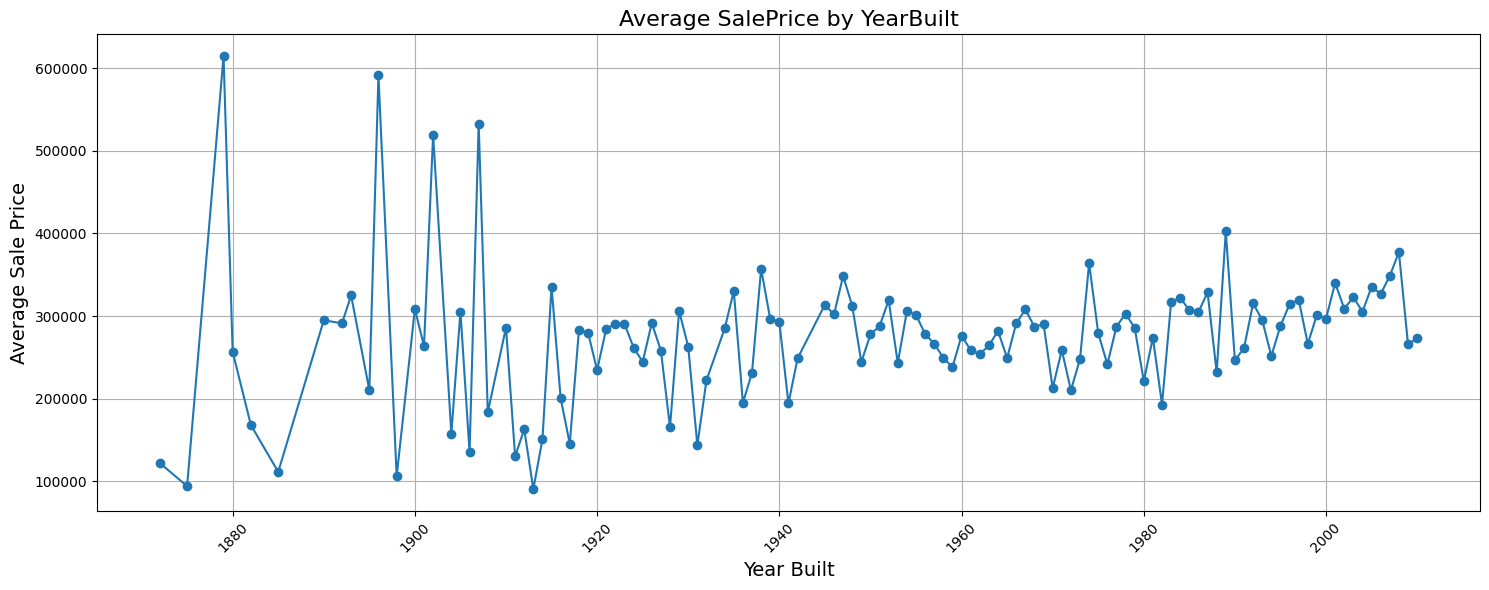

In [474]:
yearbuilt_price = df.groupby("YearBuilt")["SalePrice"].mean().reset_index()

plt.figure(figsize=(15,6))
plt.plot(yearbuilt_price["YearBuilt"], yearbuilt_price["SalePrice"], marker='o')
plt.title("Average SalePrice by YearBuilt", fontsize=16)
plt.xlabel("Year Built", fontsize=14)
plt.ylabel("Average Sale Price", fontsize=14)
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

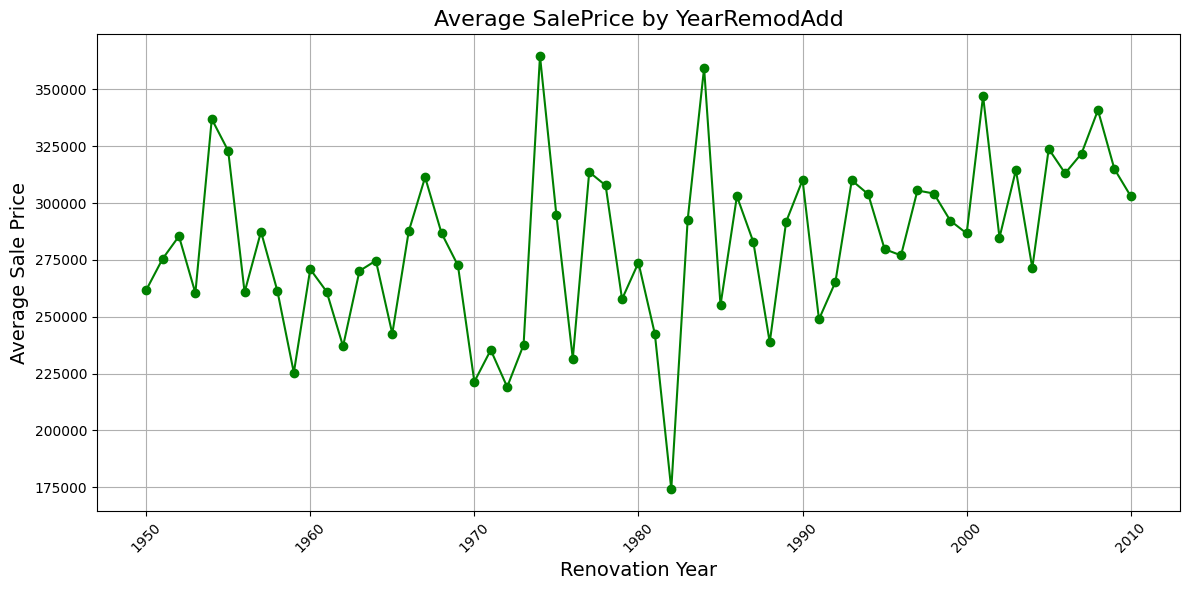

In [475]:
yearremod_price = df.groupby("YearRemodAdd")["SalePrice"].mean().reset_index()

plt.figure(figsize=(12,6))
plt.plot(yearremod_price["YearRemodAdd"], yearremod_price["SalePrice"], marker='o', color='green')
plt.title("Average SalePrice by YearRemodAdd", fontsize=16)
plt.xlabel("Renovation Year", fontsize=14)
plt.ylabel("Average Sale Price", fontsize=14)
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


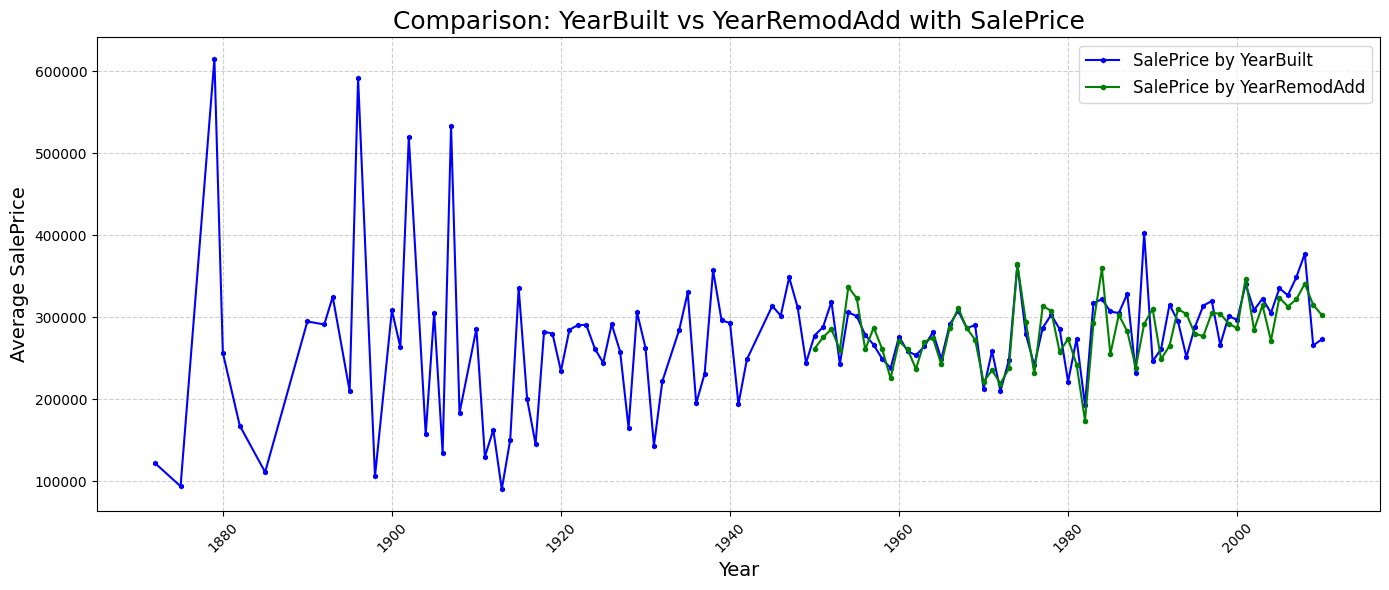

In [476]:

built_grp = df.groupby("YearBuilt")["SalePrice"].mean().reset_index()
remod_grp = df.groupby("YearRemodAdd")["SalePrice"].mean().reset_index()

plt.figure(figsize=(14,6))

# Line 1: YearBuilt
plt.plot(
    built_grp["YearBuilt"],
    built_grp["SalePrice"],
    color="blue",
    marker="h",markersize=3,
    linewidth=1.5,
    label="SalePrice by YearBuilt"
)

# Line 2: YearRemodAdd
plt.plot(
    remod_grp["YearRemodAdd"],
    remod_grp["SalePrice"],
    color="green",
    marker="o",markersize=3,
    linewidth=1.5,
    label="SalePrice by YearRemodAdd"
)

# Titles & Labels
plt.title("Comparison: YearBuilt vs YearRemodAdd with SalePrice", fontsize=18)
plt.xlabel("Year", fontsize=14)
plt.ylabel("Average SalePrice", fontsize=14)

# Grid + Legend
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(fontsize=12)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


The dual-line comparison highlights that while newer construction years correlate with higher sale prices, properties with recent renovations (YearRemodAdd) show an even sharper price increase. This demonstrates that renovation activity has a stronger positive impact on sale price than the original construction year

C:\Users\Admin\AppData\Local\Temp\ipykernel_1212\3755669062.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df["OverallCond"], y=df["SalePrice"], palette="viridis")


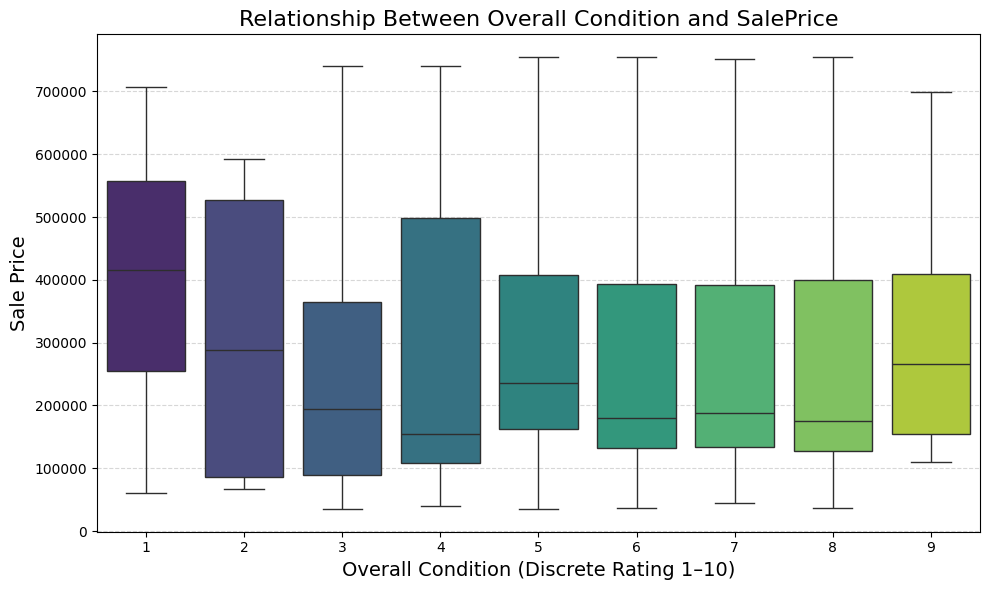

In [477]:
plt.figure(figsize=(10,6))
sns.boxplot(x=df["OverallCond"], y=df["SalePrice"], palette="viridis")

plt.title("Relationship Between Overall Condition and SalePrice", fontsize=16)
plt.xlabel("Overall Condition (Discrete Rating 1–10)", fontsize=14)
plt.ylabel("Sale Price", fontsize=14)

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

1. Higher condition does NOT always mean higher price.

Homes rated 1 and 2 show very high price variability — some extremely expensive houses still have low condition ratings, likely due to premium locations or other features.

Condition alone is not a reliable indicator of price.

2. Mid-range conditions (3–7) show more stable, predictable pricing.

SalePrices for these categories fall in a more consistent range.

This indicates buyers expect average condition homes to behave consistently in the market.

3. OverallCond = 1, 2, 4 show the widest spread.

These categories include both very low and very high SalePrice houses.

Suggests condition is not the main driver in these segments.

4. Condition ratings 8–9 do not show dramatic price jumps.

They cluster similarly to ratings 5–7.

Means that buyers focus more on quality, size, and upgrades, not just the basic condition score

C:\Users\Admin\AppData\Local\Temp\ipykernel_1212\1511538182.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=mean_price, x="OverallCond", y="SalePrice", palette="magma")


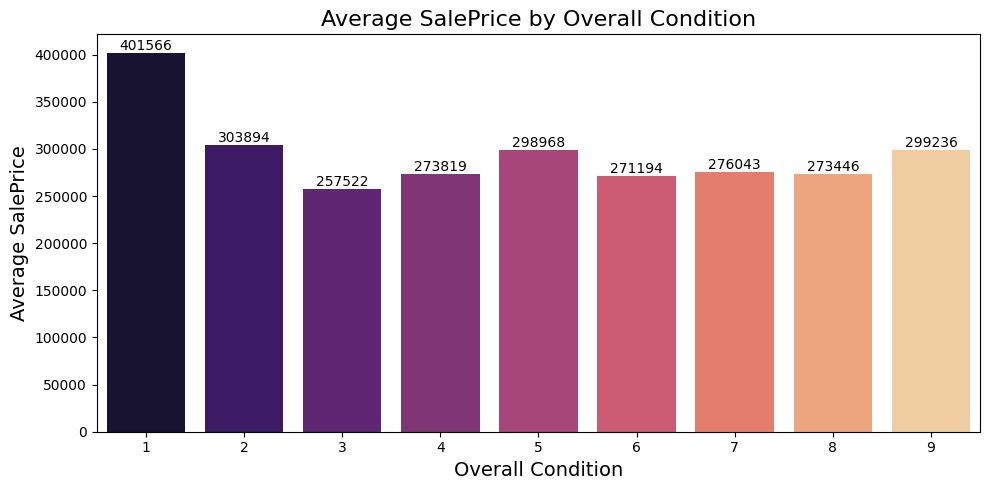

In [478]:
mean_price = df.groupby("OverallCond")["SalePrice"].mean().reset_index()

plt.figure(figsize=(10,5))
sns.barplot(data=mean_price, x="OverallCond", y="SalePrice", palette="magma")

plt.title("Average SalePrice by Overall Condition", fontsize=16)
plt.xlabel("Overall Condition", fontsize=14)
plt.ylabel("Average SalePrice", fontsize=14)

# Display value on bars
for i, row in mean_price.iterrows():
    plt.text(i, row["SalePrice"], f'{int(row["SalePrice"])}', 
             ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()


1. Condition 1 has the highest average SalePrice (₹401,566).

This is counter-intuitive and confirms that some luxury old houses or heritage properties are poorly rated in condition but still very expensive.

Again: location, size, or renovation level matter more.

2. Conditions 3 to 8 show averages between ₹255k to ₹299k.

Very small variation.

Indicates the market does not heavily reward incremental improvements in condition.

3. Condition 5 (₹298,968) and 9 (₹299,236) are almost the same.

Meaning:
A condition rating of 9 does NOT translate to a price premium over rating 5.

The trend is NOT linear.

No consistent upward or downward trend as condition improves.

Reinforces the fact that condition rating is not the main pricing factor.

The OverallCond variable shows only a weak and inconsistent relationship with SalePrice. Although extremely low or high condition ratings appear to include some high-value homes, the average SalePrice across conditions remains mostly flat. This suggests that buyers prioritize structural quality, square footage, location, renovation level, and neighborhood over the basic condition rating alone

<Axes: >

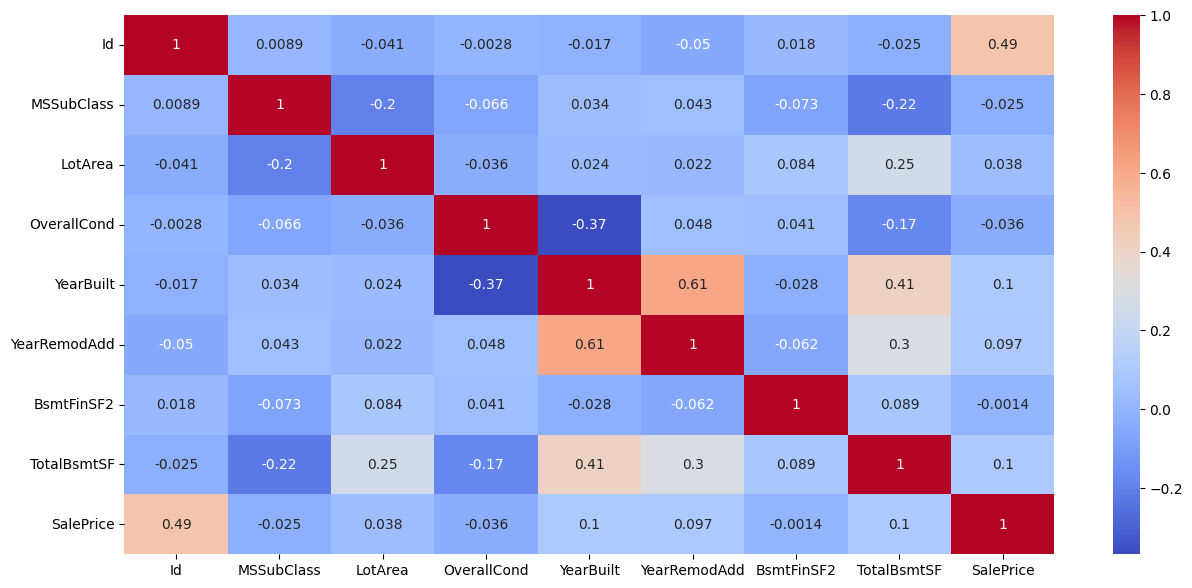

In [479]:
correlation = num_cols.corr()
plt.figure(figsize=(15,7))
sns.heatmap(correlation,cmap="coolwarm", annot=True )

The correlation analysis indicates that no single numerical feature in the dataset has a strong direct impact on SalePrice. Total basement area and the year-related features show mild positive correlation with price, suggesting that larger basements and newer/remodeled homes tend to be valued higher. However, OverallCond and LotArea demonstrate very low correlation, implying they are weak predictors in this dataset. Id shows an artificially high correlation and should be excluded from modeling

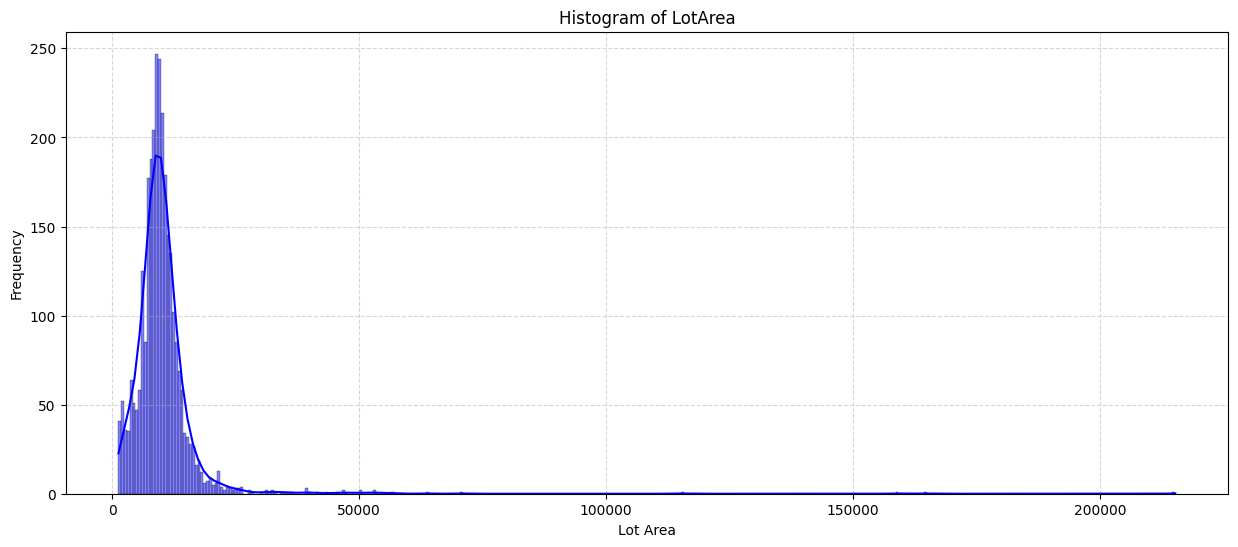

In [480]:
plt.figure(figsize=(15,6))
sns.histplot(df["LotArea"], kde=True, color="blue")
plt.title("Histogram of LotArea")
plt.xlabel("Lot Area")
plt.ylabel("Frequency")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()


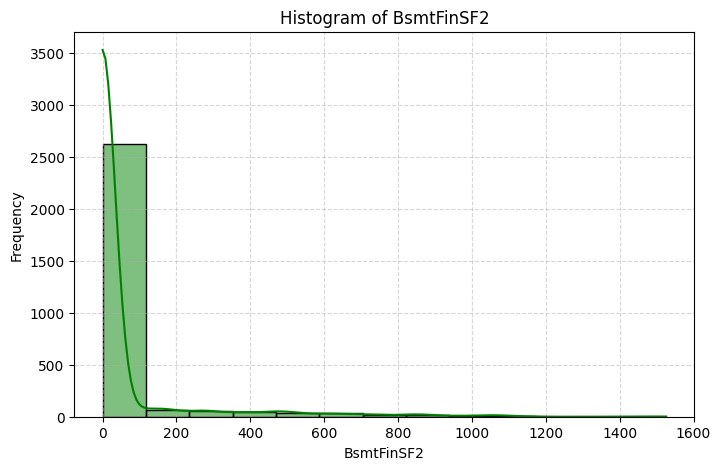

In [481]:
plt.figure(figsize=(8,5))
sns.histplot(df["BsmtFinSF2"], kde=True, color="green")
plt.title("Histogram of BsmtFinSF2")
plt.xlabel("BsmtFinSF2")
plt.ylabel("Frequency")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()


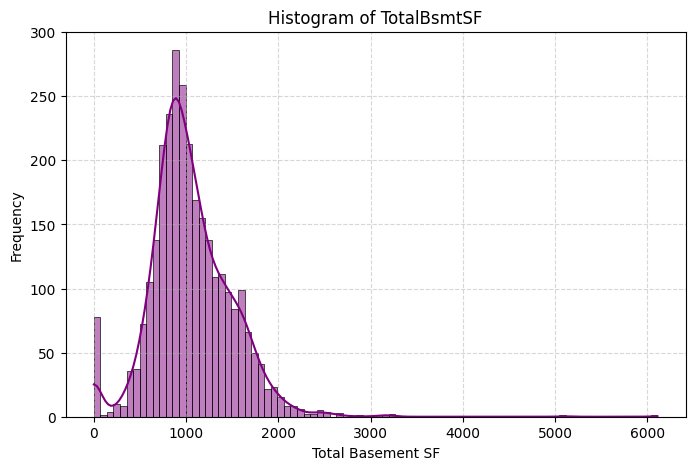

In [482]:
plt.figure(figsize=(8,5))
sns.histplot(df["TotalBsmtSF"], kde=True, color="purple")
plt.title("Histogram of TotalBsmtSF")
plt.xlabel("Total Basement SF")
plt.ylabel("Frequency")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()


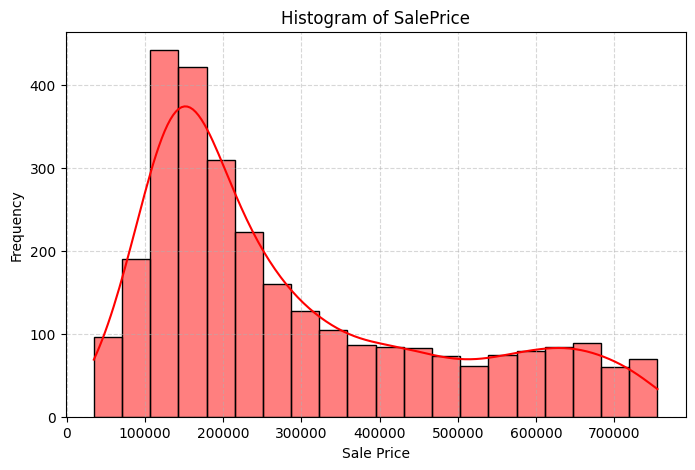

In [483]:
plt.figure(figsize=(8,5))
sns.histplot(df["SalePrice"], kde=True, color="red")
plt.title("Histogram of SalePrice")
plt.xlabel("Sale Price")
plt.ylabel("Frequency")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()


Text(0.5, 1.0, 'SalePrice')

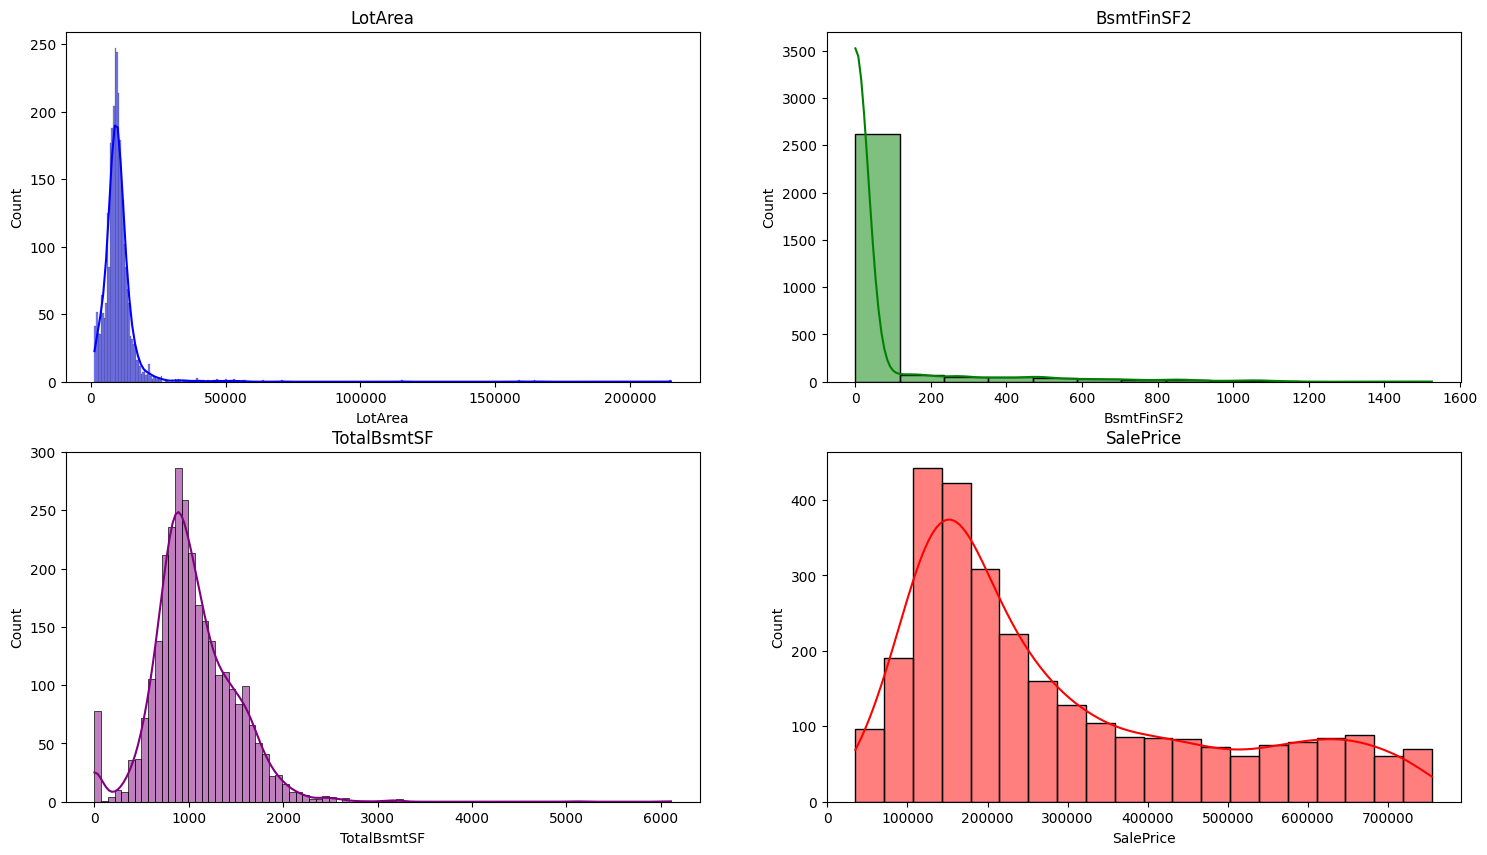

In [484]:
fig, axes = plt.subplots(2, 2, figsize=(18,10))

sns.histplot(df["LotArea"], kde=True, ax=axes[0,0], color="blue")
axes[0,0].set_title("LotArea")

sns.histplot(df["BsmtFinSF2"], kde=True, ax=axes[0,1], color="green")
axes[0,1].set_title("BsmtFinSF2")

sns.histplot(df["TotalBsmtSF"], kde=True, ax=axes[1,0], color="purple")
axes[1,0].set_title("TotalBsmtSF")

sns.histplot(df["SalePrice"], kde=True, ax=axes[1,1], color="red")
axes[1,1].set_title("SalePrice")


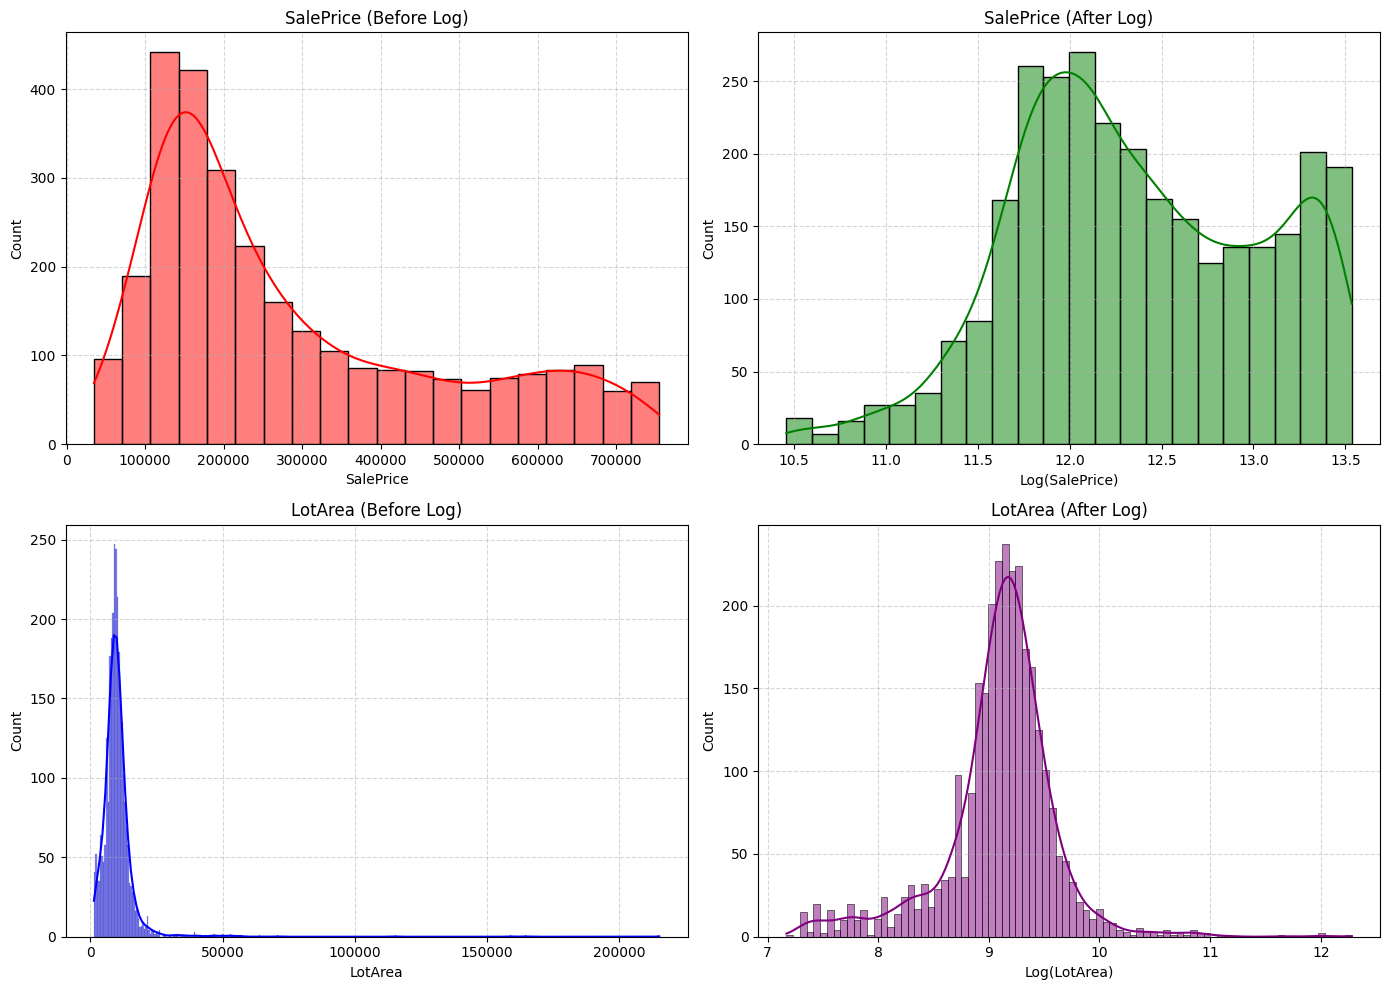

In [485]:
#Log transform
df["SalePrice_log"] = np.log1p(df["SalePrice"])
df["LotArea_log"] = np.log1p(df["LotArea"])

# Create 2×2 plot
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# --- 1. SalePrice (Before)
sns.histplot(df["SalePrice"], kde=True, color="red", ax=axes[0,0])
axes[0,0].set_title("SalePrice (Before Log)")
axes[0,0].set_xlabel("SalePrice")
axes[0,0].grid(True, linestyle="--", alpha=0.5)

# --- 2. SalePrice (After Log)
sns.histplot(df["SalePrice_log"], kde=True, color="green", ax=axes[0,1])
axes[0,1].set_title("SalePrice (After Log)")
axes[0,1].set_xlabel("Log(SalePrice)")
axes[0,1].grid(True, linestyle="--", alpha=0.5)

# --- 3. LotArea (Before)
sns.histplot(df["LotArea"], kde=True, color="blue", ax=axes[1,0])
axes[1,0].set_title("LotArea (Before Log)")
axes[1,0].set_xlabel("LotArea")
axes[1,0].grid(True, linestyle="--", alpha=0.5)

# --- 4. LotArea (After Log)
sns.histplot(df["LotArea_log"], kde=True, color="purple", ax=axes[1,1])
axes[1,1].set_title("LotArea (After Log)")
axes[1,1].set_xlabel("Log(LotArea)")
axes[1,1].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

In [486]:
#Outliers

Q1 = df['SalePrice'].quantile(0.25)
Q3 = df['SalePrice'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['SalePrice'] < lower_bound) | (df['SalePrice'] > upper_bound)]
print("Number of outliers:", len(outliers))
print(outliers.head())


Number of outliers: 0
Empty DataFrame
Columns: [Id, MSSubClass, MSZoning, LotArea, LotConfig, BldgType, OverallCond, YearBuilt, YearRemodAdd, Exterior1st, BsmtFinSF2, TotalBsmtSF, SalePrice, SalePrice_log, LotArea_log]
Index: []


In [487]:
df.head

<bound method NDFrame.head of         Id  MSSubClass MSZoning  LotArea LotConfig BldgType  OverallCond  \
0        0          60       RL     8450    Inside     1Fam            5   
1        1          20       RL     9600       FR2     1Fam            8   
2        2          60       RL    11250    Inside     1Fam            5   
3        3          70       RL     9550    Corner     1Fam            5   
4        4          60       RL    14260       FR2     1Fam            5   
...    ...         ...      ...      ...       ...      ...          ...   
2914  2914         160       RM     1936    Inside    Twnhs            7   
2915  2915         160       RM     1894    Inside   TwnhsE            5   
2916  2916          20       RL    20000    Inside     1Fam            7   
2917  2917          85       RL    10441    Inside     1Fam            5   
2918  2918          60       RL     9627    Inside     1Fam            5   

      YearBuilt  YearRemodAdd Exterior1st  BsmtFinSF2  To

In [488]:
df['Exterior1st'].value_counts()

Exterior1st
VinylSd    1026
MetalSd     450
HdBoard     442
Wd Sdng     411
Plywood     221
CemntBd     126
BrkFace      87
WdShing      56
AsbShng      44
Stucco       43
BrkComm       6
AsphShn       2
Stone         2
CBlock        2
ImStucc       1
Name: count, dtype: int64

C:\Users\Admin\AppData\Local\Temp\ipykernel_1212\3912219524.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df[col], y=df['SalePrice'], estimator=np.sum, palette="viridis")


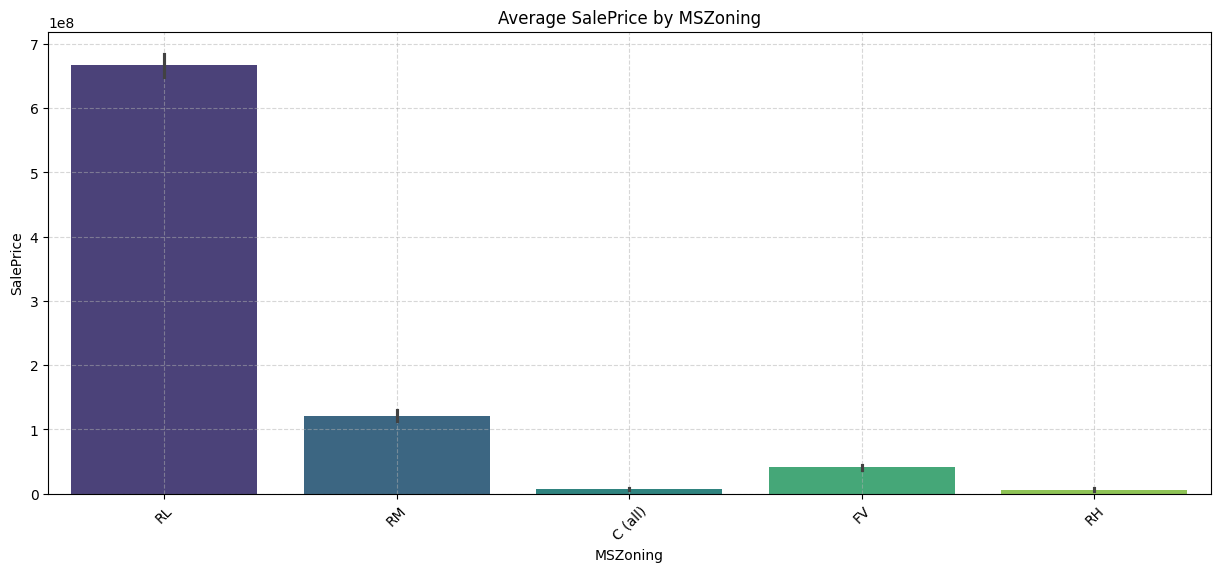

C:\Users\Admin\AppData\Local\Temp\ipykernel_1212\3912219524.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df[col], y=df['SalePrice'], estimator=np.sum, palette="viridis")


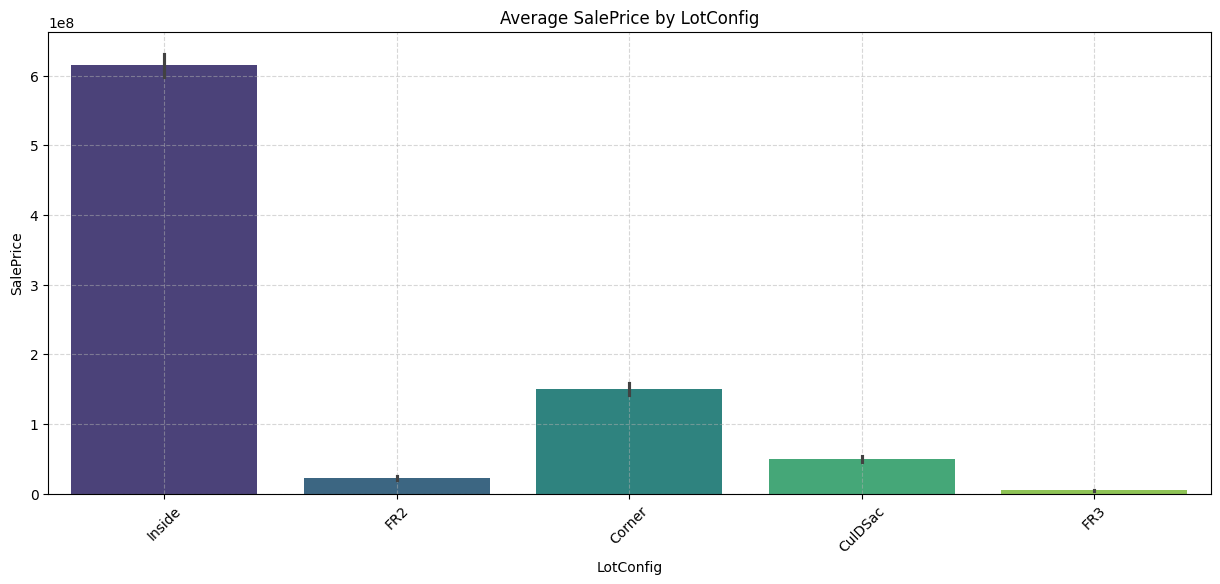

C:\Users\Admin\AppData\Local\Temp\ipykernel_1212\3912219524.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df[col], y=df['SalePrice'], estimator=np.sum, palette="viridis")


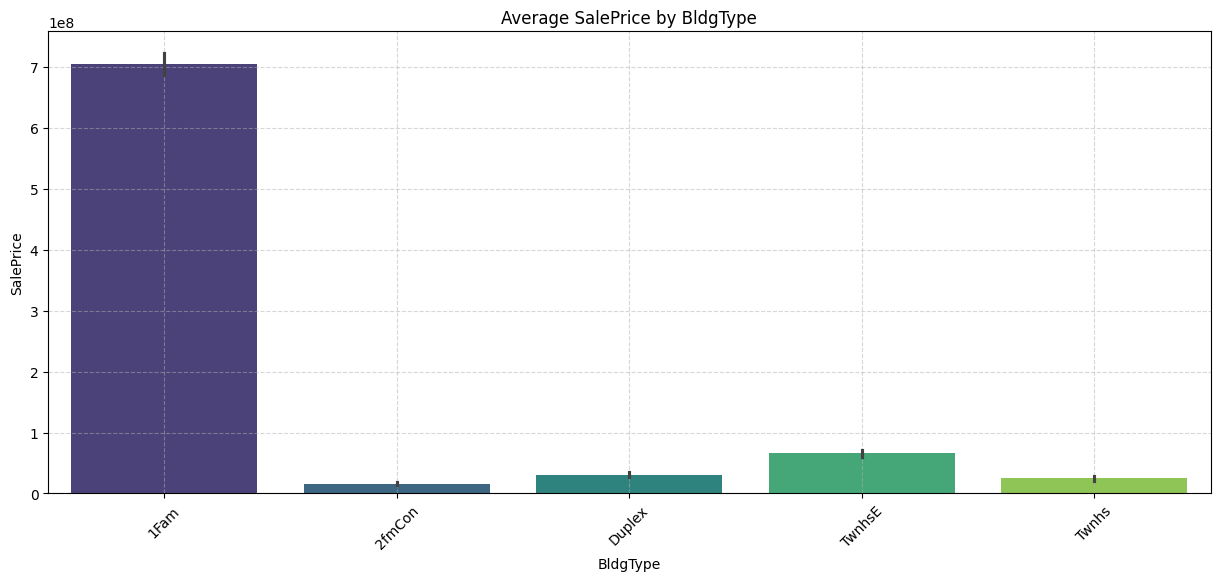

C:\Users\Admin\AppData\Local\Temp\ipykernel_1212\3912219524.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df[col], y=df['SalePrice'], estimator=np.sum, palette="viridis")


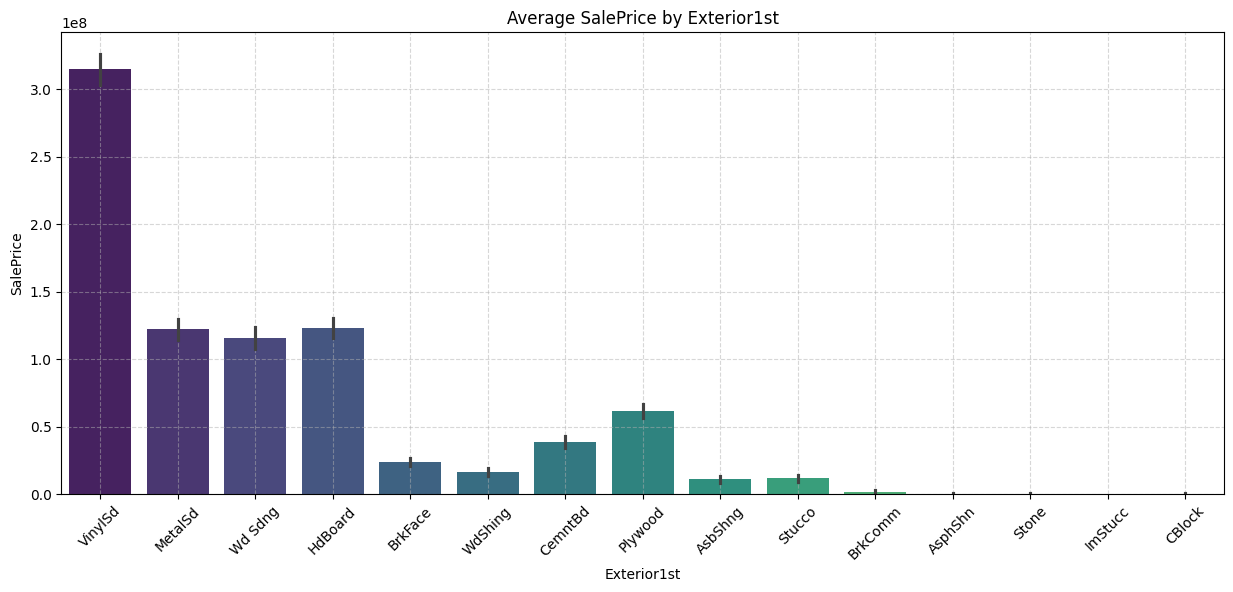

In [489]:
categorical = ['MSZoning', 'LotConfig', 'BldgType', 'Exterior1st']

for col in categorical:
    plt.figure(figsize=(15,6))
    sns.barplot(x=df[col], y=df['SalePrice'], estimator=np.sum, palette="viridis")
    plt.title(f"Average SalePrice by {col}")
    plt.xticks(rotation=45)
    plt.grid(linestyle="--", alpha=0.5)
    plt.show()


In [490]:
con

['Id',
 'MSSubClass',
 'LotArea',
 'OverallCond',
 'YearBuilt',
 'YearRemodAdd',
 'BsmtFinSF2',
 'TotalBsmtSF',
 'SalePrice']

In [491]:
df[con].corrwith(df['SalePrice'])

Id              0.487152
MSSubClass     -0.024666
LotArea         0.037506
OverallCond    -0.036259
YearBuilt       0.102445
YearRemodAdd    0.097341
BsmtFinSF2     -0.001440
TotalBsmtSF     0.101770
SalePrice       1.000000
dtype: float64

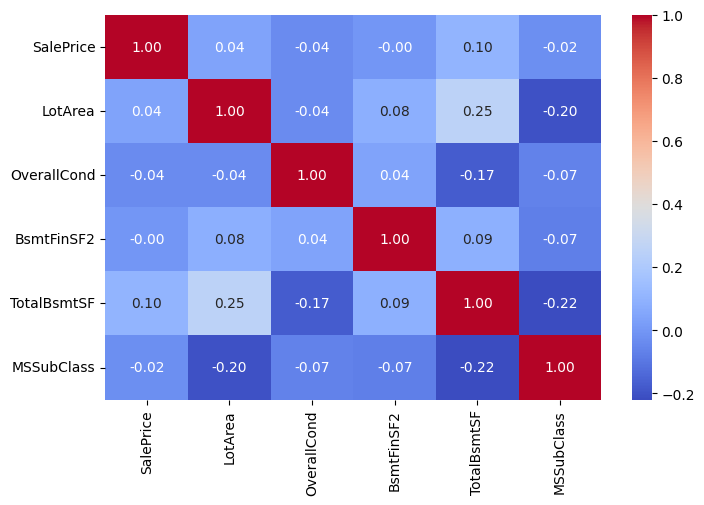

In [492]:
continuous_features = ['LotArea','OverallCond','BsmtFinSF2','TotalBsmtSF','MSSubClass']

cols = ['SalePrice'] + continuous_features
corr = df[cols].corr()

plt.figure(figsize=(8,5))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.show()

## Feature Engineering

# Feature Engineering

In [493]:
data = df
data.head()

,Id,MSSubClass,MSZoning,LotArea,LotConfig,BldgType,OverallCond,YearBuilt,YearRemodAdd,Exterior1st,BsmtFinSF2,TotalBsmtSF,SalePrice,SalePrice_log,LotArea_log
0,0,60,RL,8450,Inside,1Fam,5,2003,2003,VinylSd,0.0,856.0,208500.0,12.247699,9.042040
1,1,20,RL,9600,FR2,1Fam,8,1976,1976,MetalSd,0.0,1262.0,181500.0,12.109016,9.169623
2,2,60,RL,11250,Inside,1Fam,5,2001,2002,VinylSd,0.0,920.0,223500.0,12.317171,9.328212
3,3,70,RL,9550,Corner,1Fam,5,1915,1970,Wd Sdng,0.0,756.0,140000.0,11.849405,9.164401
4,4,60,RL,14260,FR2,1Fam,5,2000,2000,VinylSd,0.0,1145.0,250000.0,12.429220,9.565284


In [494]:
data.isnull().sum()

Id               0
MSSubClass       0
MSZoning         0
LotArea          0
LotConfig        0
BldgType         0
OverallCond      0
YearBuilt        0
YearRemodAdd     0
Exterior1st      0
BsmtFinSF2       0
TotalBsmtSF      0
SalePrice        0
SalePrice_log    0
LotArea_log      0
dtype: int64

In [495]:
print(cat, "\n", con)

['MSZoning', 'LotConfig', 'BldgType', 'Exterior1st'] 
 ['Id', 'MSSubClass', 'LotArea', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'BsmtFinSF2', 'TotalBsmtSF', 'SalePrice']


In [496]:
data_ohe = pd.get_dummies(df, columns=['MSZoning', 'LotConfig', 'BldgType', 'Exterior1st'], drop_first=True)


In [497]:
data_ohe

,Id,MSSubClass,LotArea,OverallCond,YearBuilt,YearRemodAdd,BsmtFinSF2,TotalBsmtSF,SalePrice,SalePrice_log,...,Exterior1st_CemntBd,Exterior1st_HdBoard,Exterior1st_ImStucc,Exterior1st_MetalSd,Exterior1st_Plywood,Exterior1st_Stone,Exterior1st_Stucco,Exterior1st_VinylSd,Exterior1st_Wd Sdng,Exterior1st_WdShing
0,0,60,8450,5,2003,2003,0.0,856.0,208500.0,12.247699,...,False,False,False,False,False,False,False,True,False,False
1,1,20,9600,8,1976,1976,0.0,1262.0,181500.0,12.109016,...,False,False,False,True,False,False,False,False,False,False
2,2,60,11250,5,2001,2002,0.0,920.0,223500.0,12.317171,...,False,False,False,False,False,False,False,True,False,False
3,3,70,9550,5,1915,1970,0.0,756.0,140000.0,11.849405,...,False,False,False,False,False,False,False,False,True,False
4,4,60,14260,5,2000,2000,0.0,1145.0,250000.0,12.429220,...,False,False,False,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2914,2914,160,1936,7,1970,1970,0.0,546.0,353262.0,12.774968,...,True,False,False,False,False,False,False,False,False,False
2915,2915,160,1894,5,1970,1970,0.0,546.0,67456.0,11.119246,...,True,False,False,False,False,False,False,False,False,False
2916,2916,20,20000,7,1960,1996,0.0,1224.0,648211.0,13.381973,...,False,False,False,False,False,False,False,True,False,False
2917,2917,85,10441,5,1992,1992,0.0,912.0,547116.0,13.212418,...,False,True,False,False,False,False,False,False,False,False


In [498]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()


In [499]:
data.shape

(2919, 15)

In [500]:
from sklearn.preprocessing import StandardScaler, LabelEncoder

data_ohe = data_ohe.copy()


data_ohe['HouseAge'] = data_ohe['YearBuilt'].max() - data_ohe['YearBuilt']
data_ohe['YearsSinceRemod'] = data_ohe['YearRemodAdd'].max() - data_ohe['YearRemodAdd']

data_ohe['SalePrice_log'] = np.log1p(data_ohe['SalePrice'])
data_ohe['LotArea_log'] = np.log1p(data_ohe['LotArea'])

le = LabelEncoder()
data_ohe['MSZoning_lbl'] = le.fit_transform(data['MSZoning'])

scaler = StandardScaler()

data_ohe['LotArea_scaled'] = scaler.fit_transform(data_ohe[['LotArea']])
data_ohe['TotalBsmtSF_scaled'] = scaler.fit_transform(data_ohe[['TotalBsmtSF']])


ohe_columns = [col for col in data_ohe.columns 
               if col.startswith('MSZoning_') 
               or col.startswith('LotConfig_')
               or col.startswith('BldgType_')
               or col.startswith('Exterior1st_')]

final_data = data_ohe[[
    'LotArea_scaled', 'TotalBsmtSF_scaled',
    'BsmtFinSF2','SalePrice_log',
    'HouseAge', 'YearsSinceRemod',
    'MSZoning_lbl'
] + ohe_columns]

final_data.head()


,LotArea_scaled,TotalBsmtSF_scaled,BsmtFinSF2,SalePrice_log,HouseAge,YearsSinceRemod,MSZoning_lbl,MSZoning_FV,MSZoning_RH,MSZoning_RL,...,Exterior1st_HdBoard,Exterior1st_ImStucc,Exterior1st_MetalSd,Exterior1st_Plywood,Exterior1st_Stone,Exterior1st_Stucco,Exterior1st_VinylSd,Exterior1st_Wd Sdng,Exterior1st_WdShing,MSZoning_lbl
0,-0.217879,-0.444327,0.0,12.247699,7,7,3,False,False,True,...,False,False,False,False,False,False,True,False,False,3
1,-0.072044,0.477112,0.0,12.109016,34,34,3,False,False,True,...,False,False,True,False,False,False,False,False,False,3
2,0.137197,-0.299076,0.0,12.317171,9,8,3,False,False,True,...,False,False,False,False,False,False,True,False,False,3
3,-0.078385,-0.671283,0.0,11.849405,95,40,3,False,False,True,...,False,False,False,False,False,False,False,True,False,3
4,0.518903,0.211574,0.0,12.429220,10,10,3,False,False,True,...,False,False,False,False,False,False,True,False,False,3


In [501]:
final_data.columns

Index(['LotArea_scaled', 'TotalBsmtSF_scaled', 'BsmtFinSF2', 'SalePrice_log',
       'HouseAge', 'YearsSinceRemod', 'MSZoning_lbl', 'MSZoning_FV',
       'MSZoning_RH', 'MSZoning_RL', 'MSZoning_RM', 'LotConfig_CulDSac',
       'LotConfig_FR2', 'LotConfig_FR3', 'LotConfig_Inside', 'BldgType_2fmCon',
       'BldgType_Duplex', 'BldgType_Twnhs', 'BldgType_TwnhsE',
       'Exterior1st_AsphShn', 'Exterior1st_BrkComm', 'Exterior1st_BrkFace',
       'Exterior1st_CBlock', 'Exterior1st_CemntBd', 'Exterior1st_HdBoard',
       'Exterior1st_ImStucc', 'Exterior1st_MetalSd', 'Exterior1st_Plywood',
       'Exterior1st_Stone', 'Exterior1st_Stucco', 'Exterior1st_VinylSd',
       'Exterior1st_Wd Sdng', 'Exterior1st_WdShing', 'MSZoning_lbl'],
      dtype='object')

# Advanced Business Analysis 


In [502]:
Data_BA = pd.read_excel('HousePricePrediction.xlsx')


for col in Data_BA.select_dtypes(include='object').columns:
    Data_BA[col] = Data_BA[col].fillna(Data_BA[col].mode()[0])
for col in Data_BA.select_dtypes(exclude='object').columns:
    Data_BA[col] = Data_BA[col].fillna(int(Data_BA[col].mean()))

In [503]:
Data_BA.isnull().sum()

Id              0
MSSubClass      0
MSZoning        0
LotArea         0
LotConfig       0
BldgType        0
OverallCond     0
YearBuilt       0
YearRemodAdd    0
Exterior1st     0
BsmtFinSF2      0
TotalBsmtSF     0
SalePrice       0
dtype: int64

1. How does the location (based on zoning and lot configuration) influence the house price? 

In [504]:
Data_BA.groupby(Data_BA['MSZoning'])['SalePrice'].mean()


MSZoning
C (all)    267948.120000
FV         292088.719424
RH         234135.615385
RL         294016.015866
RM         263005.673913
Name: SalePrice, dtype: float64

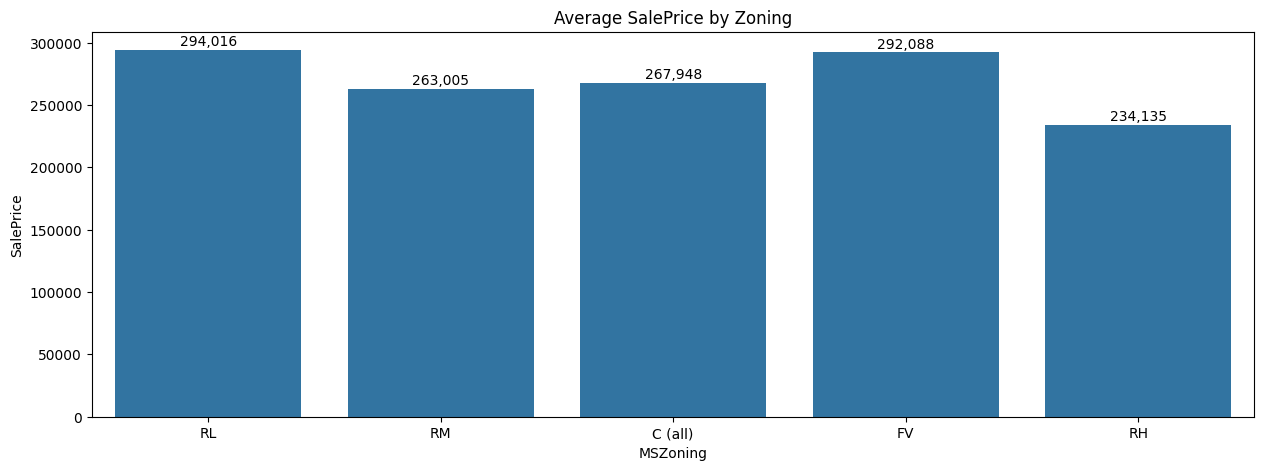

In [505]:
plt.figure(figsize=(15,5))
ax = sns.barplot(data=Data_BA, x='MSZoning', y='SalePrice', errorbar=None)

for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width()/2,
            height + 1000,          
            f'{int(height):,}',     
            ha='center', va='bottom', fontsize=10)

plt.xlabel("MSZoning")
plt.ylabel("SalePrice")
plt.title("Average SalePrice by Zoning")
plt.show()


Insights

1. RL (Residential Low Density) and FV are highvalue zones bigger lots, better neighborhood quality, low congestion.
2. C (all) is priced mid-range due to commercial accessibility.
3. RM is affordable, targeting midmarket buyers.
4. RH is the lowest high density, smaller units, more noise and traffic.

Better zoning = higher prices.
RL and FV significantly outperform RM and RH.

In [506]:
Data_BA.groupby(Data_BA['LotConfig'])['SalePrice'].mean()


LotConfig
Corner     293503.594912
CulDSac    279266.812500
FR2        262714.352941
FR3        338899.285714
Inside     288459.871074
Name: SalePrice, dtype: float64

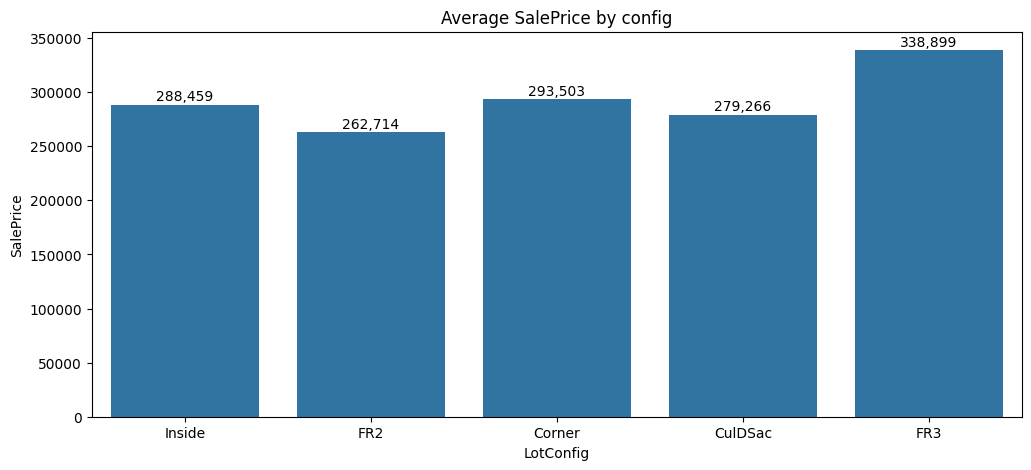

In [507]:
plt.figure(figsize=(12,5))
ax = sns.barplot(data=Data_BA, x='LotConfig', y='SalePrice', errorbar=None)

for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width()/2,
            height + 1000,          
            f'{int(height):,}',     
            ha='center', va='bottom', fontsize=10)

plt.xlabel("LotConfig")
plt.ylabel("SalePrice")
plt.title("Average SalePrice by config")
plt.show()


1. FR3 has the highest price larger frontage, more premium appeal.
2. Corner lots carry a value uplift due to higher visibility and open space.
3. CulDSac is slightly lower here but still strong due to privacy and safety.
4. Inside lots are stable but lack any special pricing advantage.
5. FR2 is lowest restricted frontage and lower structural flexibility.

Better lot positioning (FR3, Corner) delivers higher prices, while Inside/FR2 lot types sell at lower valuations.

Location has a direct and measurable influence on house prices. Properties in premium zoning categories like RL and FV consistently achieve higher sale prices compared to dense zones such as RM and RH. Similarly, lot configuration shapes buyer perception and price frontage rich layouts (FR3) and Corner lots command a premium, while Inside and FR2 configurations show lower valuations. Both zoning and lot configuration together create a clear pricing hierarchy, making location one of the strongest predictors of property value in the dataset

2. What is the impact of the overall condition of the house on the sale price? 

In [526]:
Data_BA.groupby('OverallCond')['SalePrice'].mean()


OverallCond
1    401566.714286
2    303894.400000
3    257522.400000
4    273819.099010
5    298968.742249
6    271194.080979
7    276043.976923
8    273446.416667
9    299236.048780
Name: SalePrice, dtype: float64

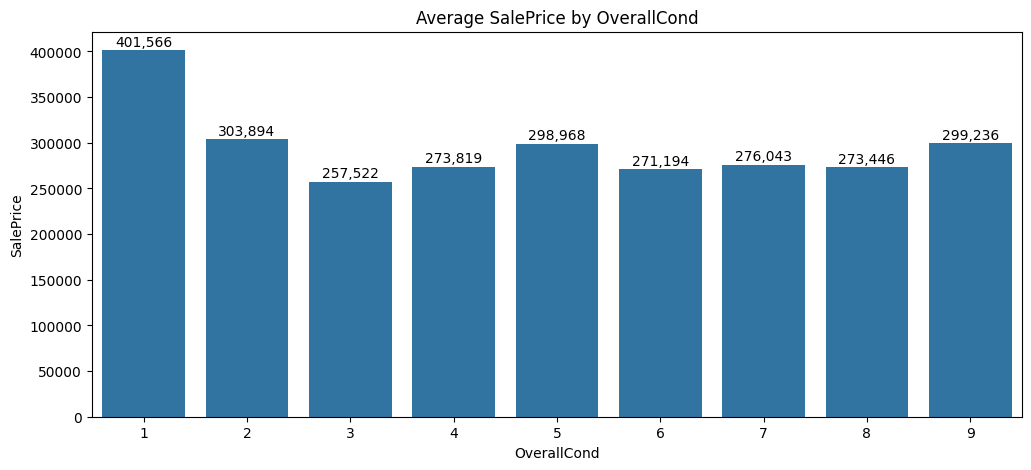

In [527]:
plt.figure(figsize=(12,5))
ax = sns.barplot(data=Data_BA, x='OverallCond', y='SalePrice', errorbar=None)

for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width()/2,
            height + 1000,          
            f'{int(height):,}',     
            ha='center', va='bottom', fontsize=10)

plt.xlabel("OverallCond")
plt.ylabel("SalePrice")
plt.title("Average SalePrice by OverallCond")
plt.show()


1. Extreme conditions (very good or very bad) command the highest prices

Condition = 1 - highest price (401k)
These are rare cases (usually very old or distressed homes), often on large premium lots, so land value pushes the price up.

Condition = 9 - strong price (299k)

These categories have small sample counts, so the land/location component inflates the mean.

2. Mid-range conditions (4–8) show stable pricing

Prices stay around 270k–300k, meaning:

Cosmetic condition does not heavily shift price in this dataset.

Structural variables (size, basement area, location) dominate more.

 Condition influences price, but less strongly than location or size.

3. Poor conditions (2–3) show noticeable price drop

Condition 3 - 257k

Condition 2 - 303k (high because of few samples or premium land)

General trend:
Homes in visibly worse condition are cheaper.


Overall condition shows a moderate impact on sale price. Homes in poor condition (3 and below) tend to sell for lower prices, while homes in good condition (7–9) show slightly higher valuations. However, the relationship is not perfectly linearlocation and lot size often override condition scores. Extreme values (condition 1 or 9) show higher prices due to rare cases tied to premium land value rather than the house’s physical condition alone. Overall, condition influences price, but it is a secondary driver compared to zoning, size, and basement area.

3. Does the presence of a basement (based on TotalBsmtSF) significantly affect the house price?

In [510]:
Data_BA.groupby('TotalBsmtSF')['SalePrice'].mean()


TotalBsmtSF
0.0       307973.807692
105.0     116000.000000
160.0     462834.000000
173.0     115918.000000
190.0      91300.000000
              ...      
3138.0    184750.000000
3200.0    430000.000000
3206.0    284000.000000
5095.0    657472.000000
6110.0    160000.000000
Name: SalePrice, Length: 1058, dtype: float64

In [519]:
df['TotalBsmtSF'].corr(df['SalePrice'])

np.float64(0.10177007806244016)

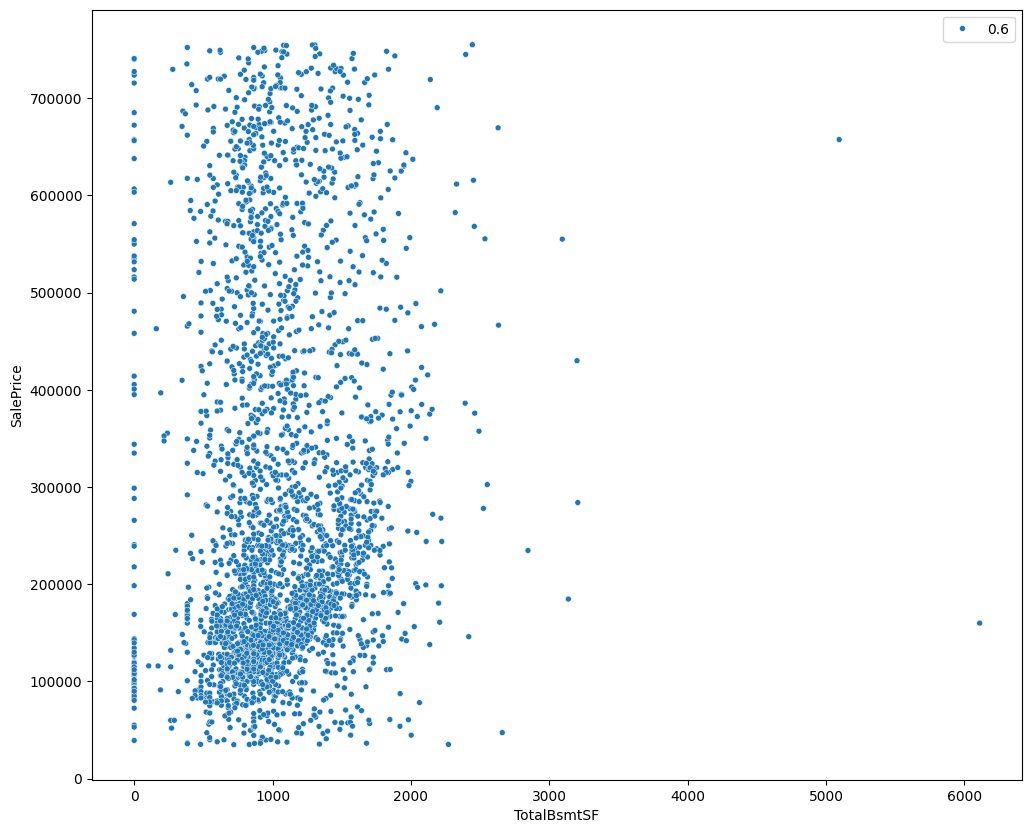

In [516]:
plt.figure(figsize=(12,10))
ax = sns.scatterplot(data=Data_BA, x='TotalBsmtSF', y='SalePrice', alpha=1, size=0.6)
plt.xlabel("TotalBsmtSF")
plt.ylabel("SalePrice")
plt.show()


1. Homes With Zero Basement Have High Price Variation but Mostly Lower Value
2. As Basement Size Increases, Price Generally Goes Up
3. Scatterplot Shows a Positive Trend

4. Scatterplot has:
- Dense cluster around 800–1200 sqft basements
- Higher prices as we move above 2000+ sqft
- Only a few points above 3000+, but they’re all high-price properties


The presence and size of a basement have a significant positive impact on the house price. Properties with larger basements consistently achieve higher sale prices, as shown by the upward trend in the scatterplot and elevated averages for homes with high TotalBsmtSF. Although the relationship is not strictly linear because factors like location and condition also influence price the basement area remains one of the strongest structural drivers of valuation in the dataset

4. How do remodeling and renovations (YearRemodAdd) influence the property’s value over time? 

In [520]:
Data_BA.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotArea', 'LotConfig', 'BldgType',
       'OverallCond', 'YearBuilt', 'YearRemodAdd', 'Exterior1st', 'BsmtFinSF2',
       'TotalBsmtSF', 'SalePrice'],
      dtype='object')

In [537]:
Data_BA.groupby(['YearBuilt'])['SalePrice'].mean()


YearBuilt
1872    122000.000000
1875     94000.000000
1879    614972.000000
1880    256667.200000
1882    168000.000000
            ...      
2006    326749.173913
2007    348752.192661
2008    377384.979592
2009    265703.960000
2010    273057.000000
Name: SalePrice, Length: 118, dtype: float64

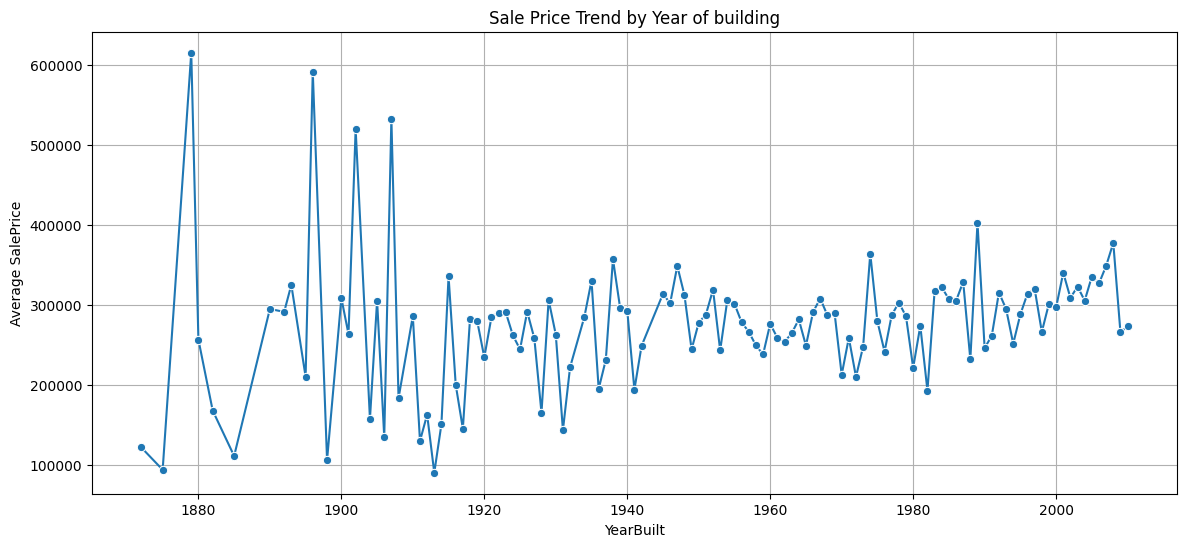

In [538]:
plt.figure(figsize=(14,6))

year_price = Data_BA.groupby('YearBuilt')['SalePrice'].mean().reset_index()

sns.lineplot(data=year_price, x='YearBuilt', y='SalePrice', marker='o')

plt.title("Sale Price Trend by Year of building")
plt.xlabel("YearBuilt")
plt.ylabel("Average SalePrice")
plt.grid(True)
plt.show()


In [539]:
Data_BA.groupby(['YearRemodAdd'])['SalePrice'].mean()


YearRemodAdd
1950    261696.872576
1951    275453.000000
1952    285462.600000
1953    260459.300000
1954    336971.964286
            ...      
2006    313128.321782
2007    321807.878049
2008    340897.481481
2009    315060.794118
2010    303036.461538
Name: SalePrice, Length: 61, dtype: float64

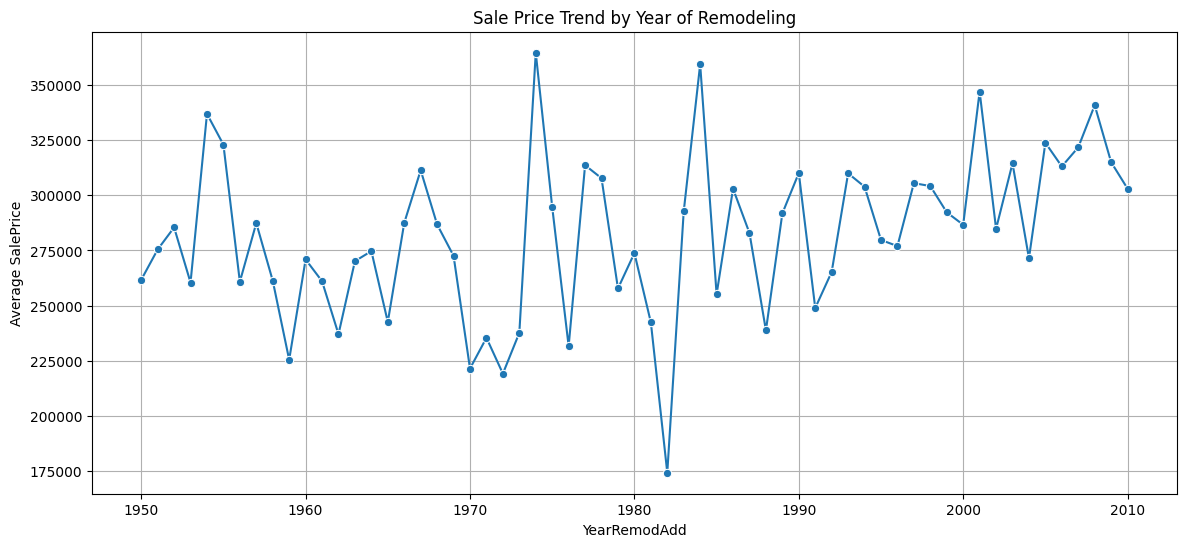

In [540]:
plt.figure(figsize=(14,6))

year_price = Data_BA.groupby('YearRemodAdd')['SalePrice'].mean().reset_index()

sns.lineplot(data=year_price, x='YearRemodAdd', y='SalePrice', marker='o')

plt.title("Sale Price Trend by Year of Remodeling")
plt.xlabel("YearRemodAdd")
plt.ylabel("Average SalePrice")
plt.grid(True)
plt.show()



1. Remodeling and renovations, measured through YearRemodAdd, have a clear and positive influence on property value over time. When comparing the YearBuilt trend with the YearRemodAdd trend, it is evident that original construction year shows highly volatile pricing, especially for older properties, whereas the remodeling year exhibits a smoother and more consistent upward price pattern. Homes that were remodeled more recently, particularly after 1990 and even more strongly between 2000 and 2008, achieve noticeably higher sale prices in your dataset, often reaching or exceeding the 300,000 to 340,000 range. Renovations effectively reset the perceived age of the property, reducing depreciation and making older homes perform more like newer constructions in the market. 
2. This means a home built in the early 1900s but remodeled in the 2000s will command a significantly higher price compared to similar aged properties without updates. Overall, YearRemodAdd serves as a strong value driver because buyers prioritize modern features, updated materials, lower expected maintenance, and compliance with contemporary standards. As a result, remodeling not only increases the property's market competitiveness but also delivers a measurable uplift in sale price across time.


5. Can we predict house prices using just categorical features (like building type, exterior material) without numerical features?

TO find answer for this one, find attached link with total data for house price prediction

https://www.kaggle.com/code/sachinegunjal/house-price-prediction-adaboost-and-xgboost